In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import MultipleLocator
import os
os.environ["PATH"] = "/opt/software-current/2023.06/x86_64/generic/software/texlive/20230313-GCC-12.3.0/bin/x86_64-linux:/Library/TeX/texbin:" + os.environ.get("PATH","")
from scipy.stats import gaussian_kde
from PIL import Image
import numpy as np

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # ---------- LaTeX ----------
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # ---------- Font sizes ----------
    "font.size": 24,            # 全局默认字号
    "axes.labelsize": 24,       # 坐标轴标题
    "axes.titlesize": 24,       # 子图标题
    "xtick.labelsize": 24,      # x 轴刻度
    "ytick.labelsize": 24,      # y 轴刻度
    "legend.fontsize": 24,      # 图例字号
    "legend.title_fontsize": 24,

    # ---------- Axes ----------
    "axes.linewidth": 1.2,      # 坐标轴边框线宽
    "axes.unicode_minus": False,

    # ---------- Lines ----------
    "lines.linewidth": 2.0,
    "lines.markersize": 8,

    # ---------- Ticks ----------
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # ---------- Legend ----------
    "legend.frameon": False,    # 论文图通常不用边框
    "legend.handlelength": 1.8,
    "legend.handletextpad": 0.4,
    "legend.borderpad": 0.3,
    "legend.labelspacing": 0.3,

    # ---------- Figure ----------
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    # ---------- PDF/PS ----------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [3]:
def plot_kde(ax, x, v, title):
    # periodic length（建议如果你知道周期，比如 4π，就直接写死）
    L = 4*np.pi

    # periodic extension
    x_ext = np.concatenate([x - L, x, x + L])
    v_ext = np.concatenate([v, v, v])

    values_ext = np.vstack([x_ext, v_ext])
    kde = gaussian_kde(values_ext)

    # grid
    xmin, xmax = 0, 4*np.pi
    vmin, vmax = -2,2

    X, V = np.meshgrid(
        np.linspace(xmin, xmax, 200),
        np.linspace(vmin, vmax, 200)
    )

    Z = kde(np.vstack([X.ravel(), V.ravel()])).reshape(X.shape)
    levels = np.linspace(0,0.015,50)
    im = ax.contourf(X, V, Z, levels=levels,extend="max")
    print(np.sum(Z))    
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("v")
    return im


263.83568344522905
263.9360184703173
262.0412537202874
262.05463492192723


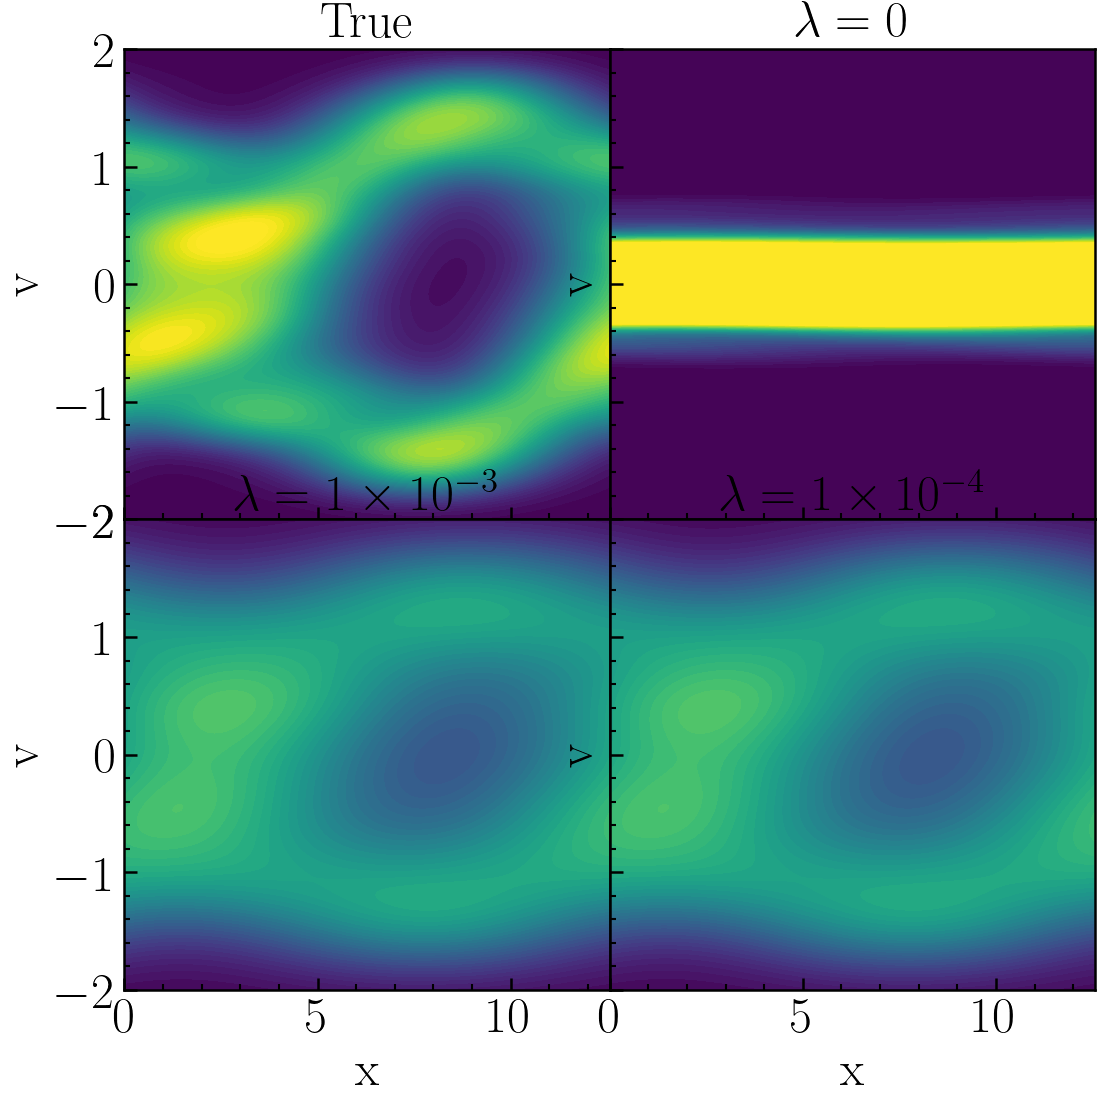

In [4]:


fig, ax = plt.subplots(
    2, 2, figsize=(8, 8), sharex=True, sharey=True,
    gridspec_kw={"wspace": 0, "hspace": 0}
)
# --- True ---
data = np.load("./simulation/data/mv_sim_seed0.npz")
plot_kde(ax[0, 0],
         data["x_paths"][1000, :],
         data["v_paths"][1000, :],
         "True")

# --- lambda = 0 ---
data = np.load("./assimilation/data_lambda_0/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(ax[0, 1],
         data["x_est"][1000, :],
         data["v_est"][1000, :],
         r"$\lambda = 0$")

# --- lambda = 1e-4 ---
data = np.load("./assimilation/data_lambda_1e_3/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(ax[1, 0],
         data["x_est"][1000, :],
         data["v_est"][1000, :],
         r"$\lambda = 1\times10^{-3}$")

# --- lambda = 1e-6 ---
data = np.load("./assimilation/data_lambda_1e_4/phase_da_kdenudge_1d1v_seed0.npz")
plot_kde(ax[1, 1],
         data["x_est"][1000, :],
         data["v_est"][1000, :],
         r"$\lambda = 1\times10^{-4}$")

plt.tight_layout()
plt.show()